## LSTM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [3]:
X_train_pad = np.load("../data/tokenization/X_train_pad.npy")
X_val_pad = np.load("../data/tokenization/X_val_pad.npy")
X_test_pad = np.load("../data/tokenization/X_test_pad.npy")

y_train = np.load("../data/tokenization/y_train.npy")
y_val = np.load("../data/tokenization/y_val.npy")
y_test = np.load("../data/tokenization/y_test.npy")

In [4]:
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train_pad shape: (34998, 200)
X_val_pad shape: (7502, 200)
X_test_pad shape: (7500, 200)
y_train shape: (34998,)
y_val shape: (7502,)
y_test shape: (7500,)


In [6]:
VOCAB_SIZE = 10000
MAX_LEN = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 10

In [9]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,mask_zero=True),
    LSTM(LSTM_UNITS, dropout=0.1, recurrent_dropout=0.1),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

In [10]:
lstm_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [16]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 119s 105ms/step - accuracy: 0.8324 - loss: 0.3956 - val_accuracy: 0.8647 - val_loss: 0.3219
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 112s 102ms/step - accuracy: 0.8968 - loss: 0.2685 - val_accuracy: 0.8655 - val_loss: 0.3249
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 109s 99ms/step - accuracy: 0.9176 - loss: 0.2183 - val_accuracy: 0.8615 - val_loss: 0.3480


In [17]:
history_df = pd.DataFrame(history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.832390,0.395551,0.864703,0.321914
1,0.896766,0.268483,0.865503,0.324928
2,0.917595,0.218254,0.861504,0.347969


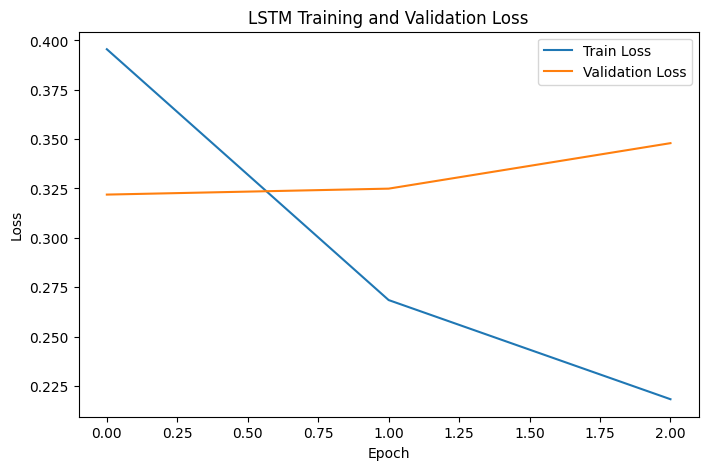

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.show()

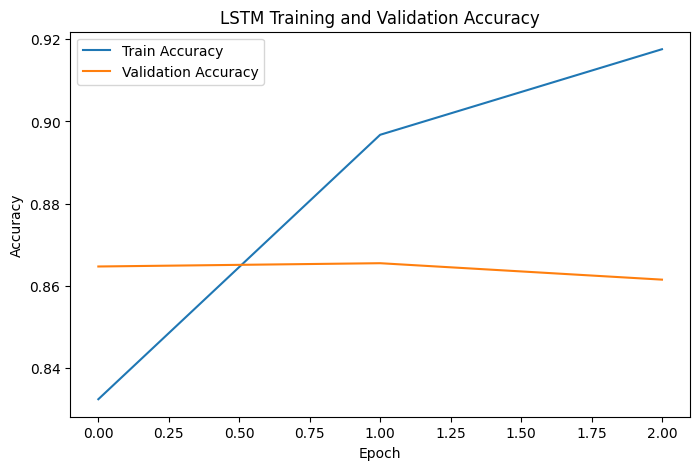

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.show()

In [20]:
val_loss, val_accuracy = lstm_model.evaluate(X_val_pad, y_val, verbose=0)

print("Validation Loss:", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 4))

Validation Loss: 0.3219
Validation Accuracy: 0.8647


In [21]:
y_val_prob = lstm_model.predict(X_val_pad)
y_val_pred = (y_val_prob > 0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step


In [22]:
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation Metrics")
print(f"Accuracy : {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall   : {val_recall:.4f}")
print(f"F1 Score : {val_f1:.4f}")

Validation Metrics
Accuracy : 0.8647
Precision: 0.8533
Recall   : 0.8808
F1 Score : 0.8669


In [23]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      3751
           1       0.85      0.88      0.87      3751

    accuracy                           0.86      7502
   macro avg       0.87      0.86      0.86      7502
weighted avg       0.87      0.86      0.86      7502



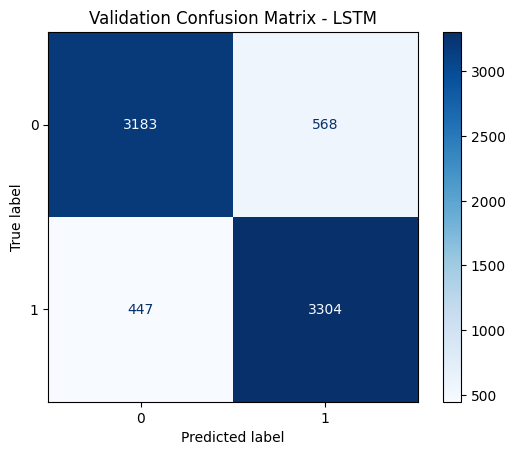

In [24]:
val_cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=val_cm)
disp.plot(cmap="Blues")
plt.title("Validation Confusion Matrix - LSTM")
plt.show()

In [25]:
test_loss, test_accuracy = lstm_model.evaluate(X_test_pad, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.3094
Test Accuracy: 0.8716


In [29]:
y_test_prob = lstm_model.predict(X_test_pad)
y_test_pred = (y_test_prob > 0.5).astype(int).flatten()

235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step


In [30]:
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Metrics")
print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Test Metrics
Accuracy : 0.8716
Precision: 0.8632
Recall   : 0.8832
F1 Score : 0.8731


In [31]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      3750
           1       0.86      0.88      0.87      3750

    accuracy                           0.87      7500
   macro avg       0.87      0.87      0.87      7500
weighted avg       0.87      0.87      0.87      7500



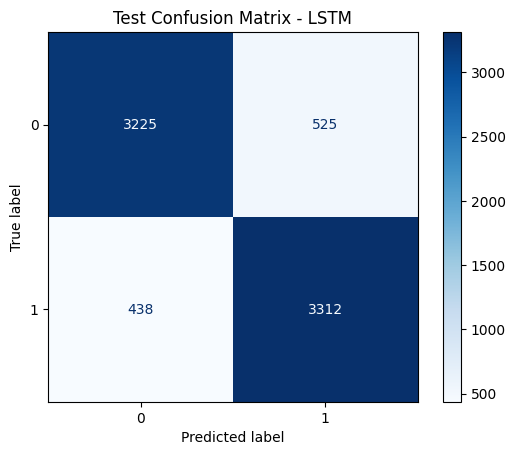

In [32]:
test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot(cmap="Blues")
plt.title("Test Confusion Matrix - LSTM")
plt.show()

In [33]:
lstm_results = pd.DataFrame([
    {
        "Model": "LSTM",
        "Validation Accuracy": val_accuracy,
        "Validation Precision": val_precision,
        "Validation Recall": val_recall,
        "Validation F1": val_f1,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1": test_f1
    }
])

lstm_results

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,LSTM,0.864703,0.853306,0.880832,0.86685,0.8716,0.863174,0.8832,0.873072


In [34]:
lstm_results.to_csv("../results/lstm_results.csv", index=False)
print("LSTM results saved.")

LSTM results saved.


In [35]:
lstm_model.save("../results/lstm_model.keras")
print("LSTM model saved.")

LSTM model saved.
